In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample - Superstore.csv", encoding="cp1252")

df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Shape:", df.shape)
display(df.head())

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


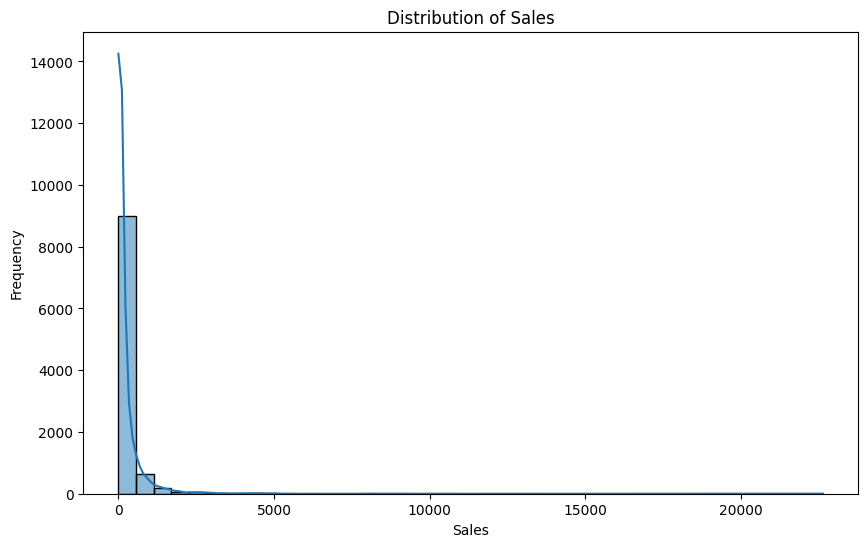

Skewness: 12.97275234181623
Mean: 229.85800083049833
Median: 54.489999999999995


In [26]:
# task 01

plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], kde=True , bins=40)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

sales_skewness = df["Sales"].skew()
sales_mean = df["Sales"].mean()
sales_median = df["Sales"].median()

print("Skewness:", sales_skewness)
print("Mean:", sales_mean)
print("Median:", sales_median)

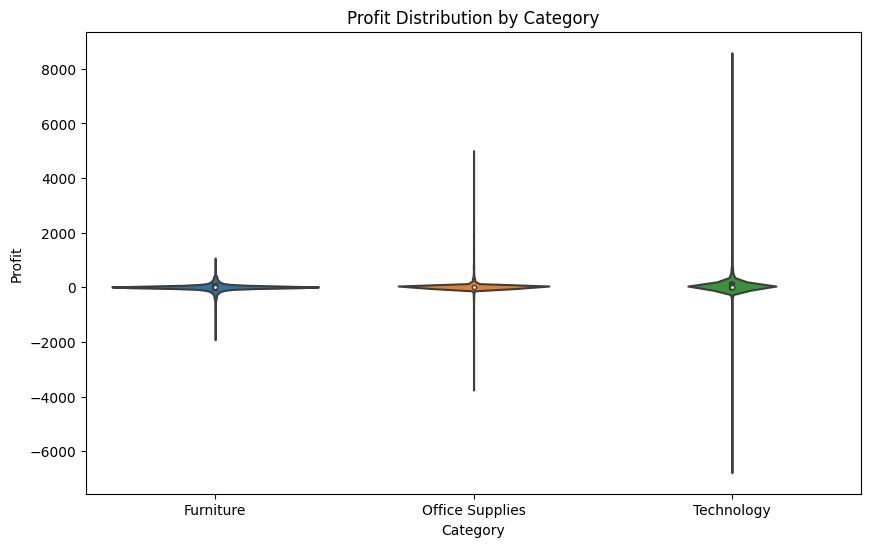

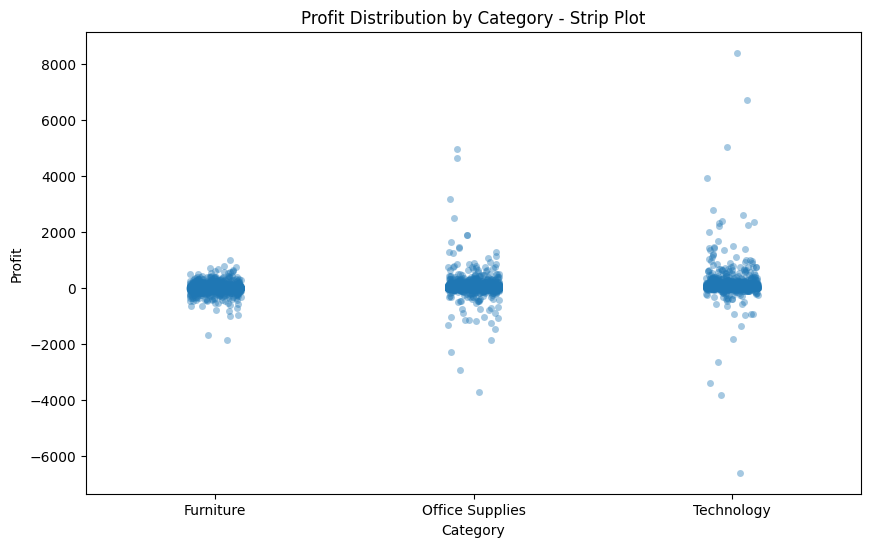

In [10]:
#task 02
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x="Category",
    y="Profit",
    jitter=True,
    alpha=0.4
)

plt.title("Profit Distribution by Category - Strip Plot")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

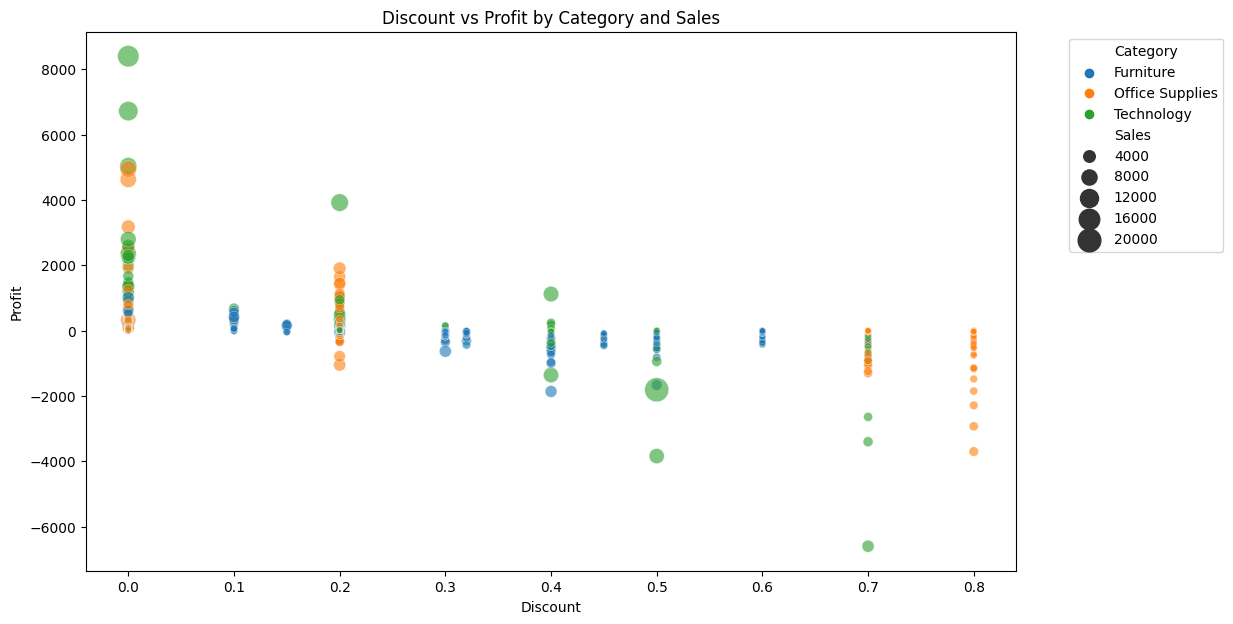

In [11]:
#task 03
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    size="Sales",
    sizes=(20, 300),
    alpha=0.6
)

plt.title("Discount vs Profit by Category and Sales")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Pearson Correlation Matrix:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Spearman Correlation Matrix:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.011466,-0.001310,-0.002416,0.012655,-0.010545
Postal Code,0.011466,1.000000,-0.002059,0.013952,0.052793,-0.005451
Sales,-0.001310,-0.002059,1.000000,0.327426,-0.056969,0.518407
Quantity,-0.002416,0.013952,0.327426,1.000000,-0.000878,0.234491
Discount,0.012655,0.052793,-0.056969,-0.000878,1.000000,-0.543350
Profit,-0.010545,-0.005451,0.518407,0.234491,-0.543350,1.000000


Pearson: -0.2194874563717685
Spearman: -0.5433501822306213


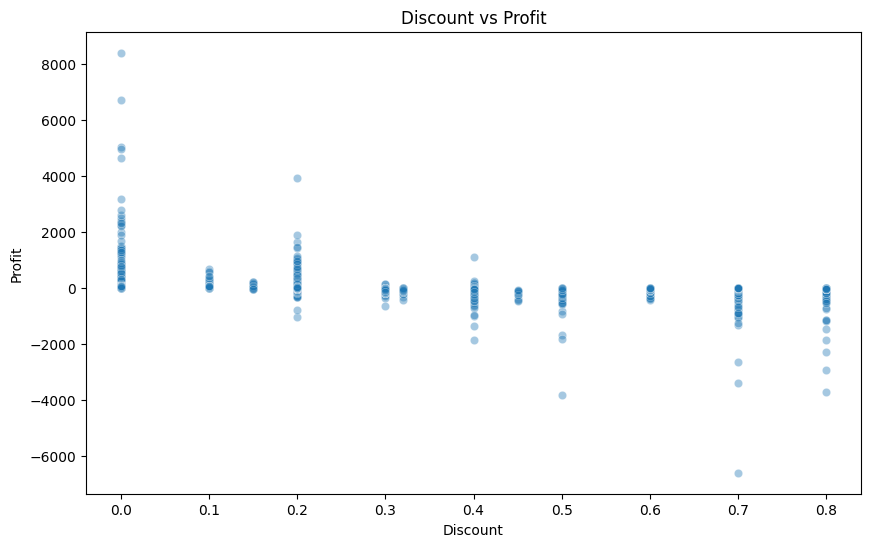

In [16]:
#task 04
numeric_df = df.select_dtypes(include=np.number)
pearson_corr = numeric_df.corr(method="pearson")

print("Pearson Correlation Matrix:")
display(pearson_corr)

spearman_corr = numeric_df.corr(method="spearman")

print("Spearman Correlation Matrix:")
display(spearman_corr)
print("Pearson:", df["Discount"].corr(df["Profit"], method="pearson"))
print("Spearman:", df["Discount"].corr(df["Profit"], method="spearman"))
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.1638,167026.415,170416.312,5.012399e+05
East,208291.2040,205516.055,264973.981,6.787812e+05
South,117298.6840,125651.313,148771.908,3.917219e+05
West,252612.7435,220853.249,251991.832,7.254578e+05
All,741999.7953,719047.032,836154.033,2.297201e+06


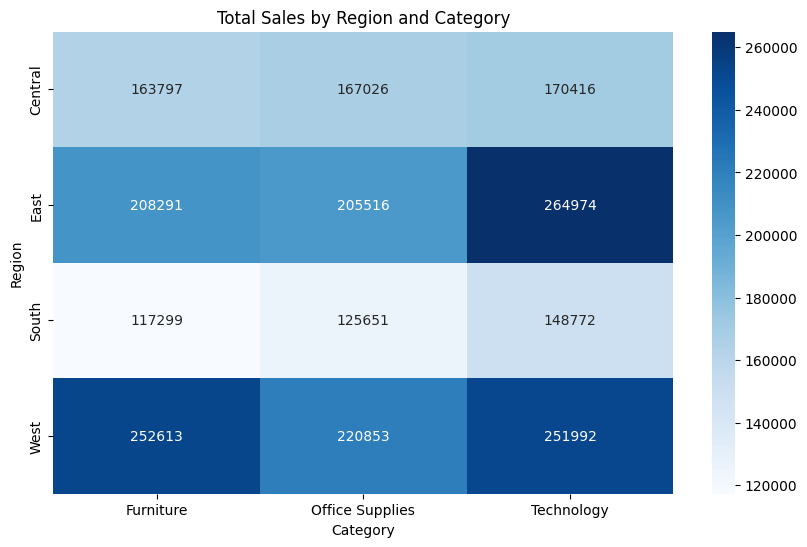

In [18]:
#task 05
sales_pivot = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    margins=True
)

display(sales_pivot)

plt.figure(figsize=(10, 6))

sns.heatmap(
    sales_pivot.iloc[:-1, :-1],
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Total Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

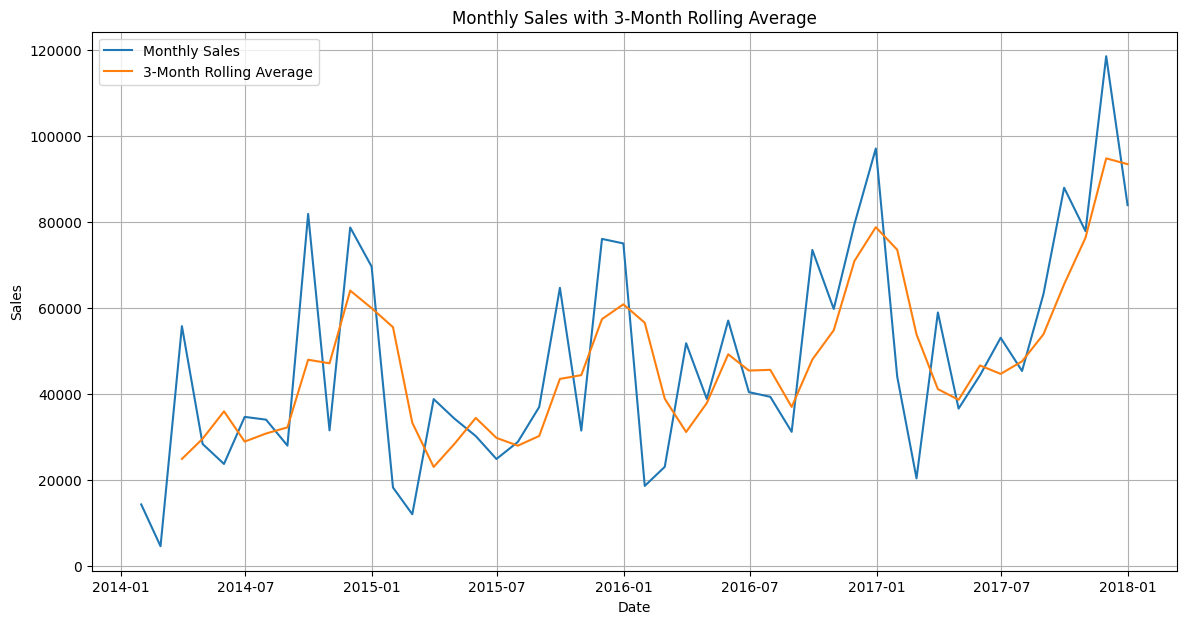

In [22]:
#task 06
df["Order Date"] = pd.to_datetime(df["Order Date"])

time_df = df.set_index("Order Date")
monthly_sales = time_df["Sales"].resample("M").sum()
rolling_sales = monthly_sales.rolling(window=3).mean()
plt.figure(figsize=(14, 7))

plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(rolling_sales, label="3-Month Rolling Average")

plt.title("Monthly Sales with 3-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

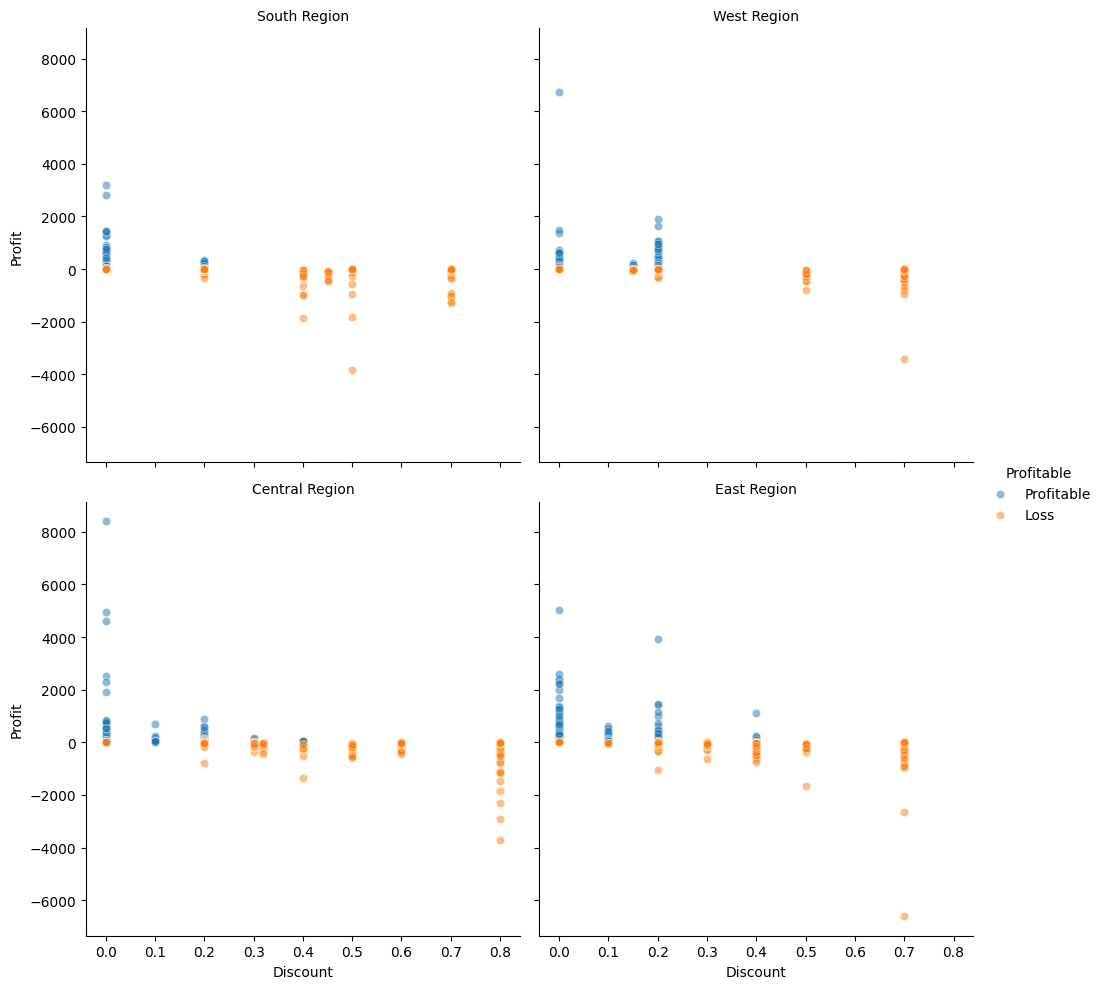

In [23]:
#task 07
df["Profitable"] = df["Profit"] > 0

df["Profitable"] = df["Profitable"].map({
    True: "Profitable",
    False: "Loss"
})
g = sns.FacetGrid(
    df,
    col="Region",
    hue="Profitable",
    col_wrap=2,
    height=5
)

g.map(
    sns.scatterplot,
    "Discount",
    "Profit",
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Discount", "Profit")
g.set_titles("{col_name} Region")

plt.show()

Most profitable order:
Order ID                               CA-2016-118689
Product Name    Canon imageCLASS 2200 Advanced Copier
Discount                                          0.0
Sales                                        17499.95
Profit                                       8399.976
Name: 6826, dtype: object

Largest loss:
Order ID                                   CA-2016-108196
Product Name    Cubify CubeX 3D Printer Double Head Print
Discount                                              0.7
Sales                                            4499.985
Profit                                          -6599.978
Name: 7772, dtype: object


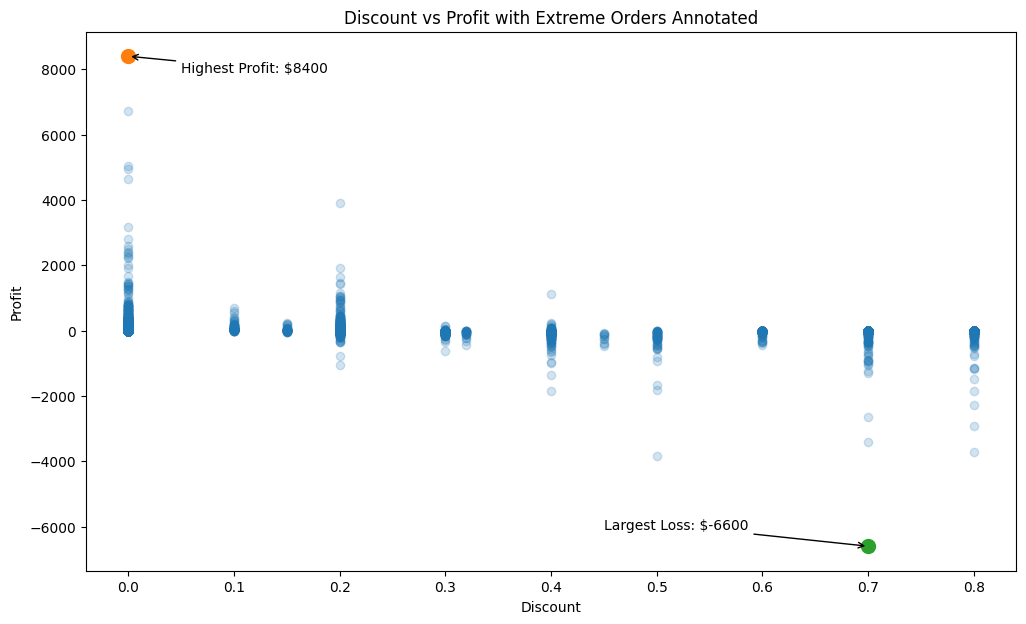

In [25]:
#task 08
max_profit = df.loc[df["Profit"].idxmax()]
max_loss = df.loc[df["Profit"].idxmin()]

print("Most profitable order:")
print(max_profit[[
    "Order ID",
    "Product Name",
    "Discount",
    "Sales",
    "Profit"
]])

print("\nLargest loss:")
print(max_loss[[
    "Order ID",
    "Product Name",
    "Discount",
    "Sales",
    "Profit"
]])
plt.figure(figsize=(12, 7))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.2
)

plt.scatter(
    max_profit["Discount"],
    max_profit["Profit"],
    s=100
)

plt.annotate(
    f"Highest Profit: ${max_profit['Profit']:.0f}",
    xy=(max_profit["Discount"], max_profit["Profit"]),
    xytext=(max_profit["Discount"] + 0.05,
            max_profit["Profit"] - 500),
    arrowprops=dict(arrowstyle="->")
)

plt.scatter(
    max_loss["Discount"],
    max_loss["Profit"],
    s=100
)

plt.annotate(
    f"Largest Loss: ${max_loss['Profit']:.0f}",
    xy=(max_loss["Discount"], max_loss["Profit"]),
    xytext=(max_loss["Discount"] - 0.25,
            max_loss["Profit"] + 500),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Discount vs Profit with Extreme Orders Annotated")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()